In [2]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] =False
# -----------------------------------------------

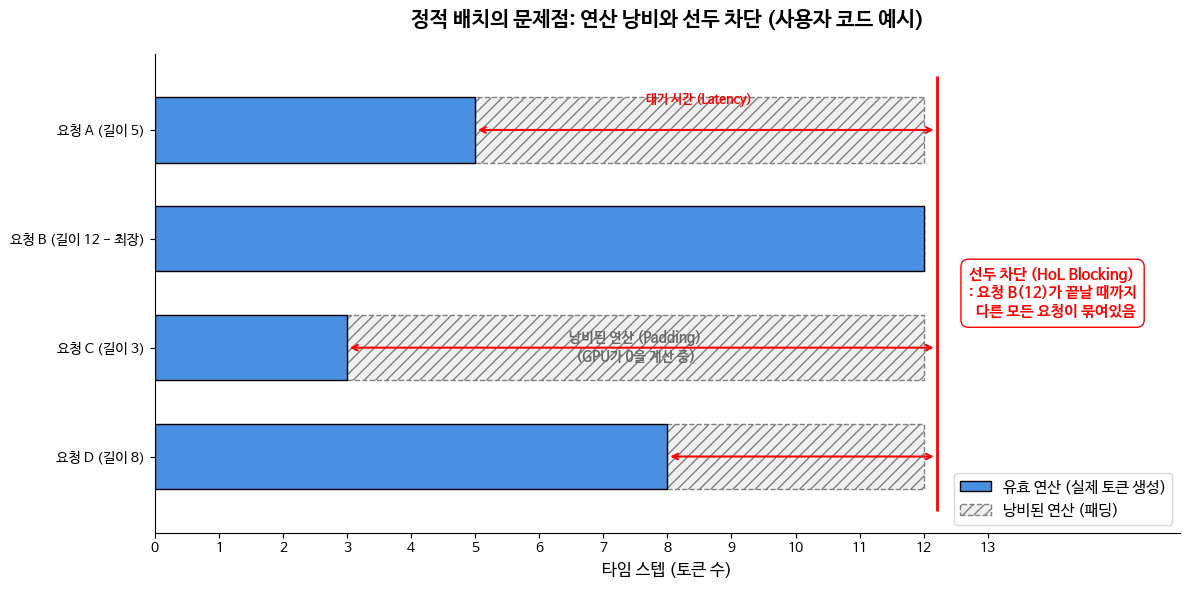

In [3]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np

# -----------------------------------------------------------
# [폰트 설정] Colab 환경용 (NanumBarunGothic)
# -----------------------------------------------------------
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# -----------------------------------------------------------
# [데이터 설정] 사용자 코드의 시나리오 반영
# -----------------------------------------------------------
# 요청 데이터: ID와 길이 (토큰 수)
requests = ['요청 A (길이 5)', '요청 B (길이 12 - 최장)', '요청 C (길이 3)', '요청 D (길이 8)']
lengths = [5, 12, 3, 8]

# 그래프는 아래에서 위로 그려지므로, 시각적으로 위에서 아래로(A->D) 보이기 위해 역순 정렬
requests_plot = requests[::-1]
valid_tokens = np.array(lengths[::-1])

# 패딩 계산 (가장 긴 요청 B의 길이에 맞춤)
max_len = 12
padding_tokens = max_len - valid_tokens

# -----------------------------------------------------------
# [그래프 그리기]
# -----------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))

# 1. 유효 연산 (파란색 막대) - 실제 의미 있는 토큰 생성 구간
ax.barh(requests_plot, valid_tokens, color='#4A90E2', label='유효 연산 (실제 토큰 생성)',
        edgecolor='black', height=0.6, zorder=3)

# 2. 낭비된 연산 (회색 빗금 막대) - 트랜스포머가 0을 계산하는 구간
bars_padding = ax.barh(requests_plot, padding_tokens, left=valid_tokens, color='#F0F0F0',
                       label='낭비된 연산 (패딩)', edgecolor='gray', linestyle='--', hatch='///', height=0.6, zorder=2)

# -----------------------------------------------------------
# [시각적 강조] GPU 낭비 및 선두 차단 표시
# -----------------------------------------------------------

# (1) 패딩 영역에 "낭비됨" 텍스트 추가 (가장 짧은 요청 C에 표시)
# 위치: 요청 C (위에서 3번째 -> 인덱스 1)의 패딩 중간 지점
padding_center_x = valid_tokens[1] + padding_tokens[1] / 2
ax.text(padding_center_x, 1, '낭비된 연산 (Padding)\n(GPU가 0을 계산 중)',
        fontsize=10, color='dimgray', ha='center', va='center', fontweight='bold')

# (2) 선두 차단 (Head-of-Line Blocking) 강조
# 가장 긴 요청 B(12토큰)가 끝나는 시점에 빨간 선 표시
line_x = 12.2
ax.vlines(x=line_x, ymin=-0.5, ymax=3.5, colors='red', linestyles='solid', linewidth=2, zorder=4)

# 대기 시간 화살표 그리기 (짧은 요청들이 긴 요청을 기다리는 시간)
for i, length in enumerate(valid_tokens):
    if length < max_len:
        # 끝난 지점부터 빨간 선까지 화살표
        ax.annotate('', xy=(line_x, i), xytext=(length, i),
                    arrowprops=dict(arrowstyle='<->', color='red', lw=1.5))

        # 맨 위 요청(A)에만 대표로 텍스트 표시
        if i == 3:
            ax.text((length + max_len)/2, i + 0.25, '대기 시간 (Latency)',
                    color='red', fontsize=9, ha='center', fontweight='bold')

# 선두 차단 설명 박스
ax.text(line_x + 0.5, 1.5, '선두 차단 (HoL Blocking)\n: 요청 B(12)가 끝날 때까지\n  다른 모든 요청이 묶여있음',
        color='red', va='center', fontweight='bold', fontsize=11,
        bbox=dict(facecolor='white', edgecolor='red', boxstyle='round,pad=0.5'))

# -----------------------------------------------------------
# [스타일링]
# -----------------------------------------------------------
ax.set_xlim(0, 16) # 오른쪽 설명 텍스트 공간 확보
ax.set_xticks(range(0, 14)) # x축 눈금 1단위로 설정
ax.set_xlabel('타임 스텝 (토큰 수)', fontsize=12)
ax.set_title(f'정적 배치의 문제점: 연산 낭비와 선두 차단 (사용자 코드 예시)', fontsize=15, fontweight='bold', pad=20)

# 불필요한 테두리 제거
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 범례 표시
ax.legend(loc='lower right', fontsize=11)

plt.tight_layout()
plt.show()

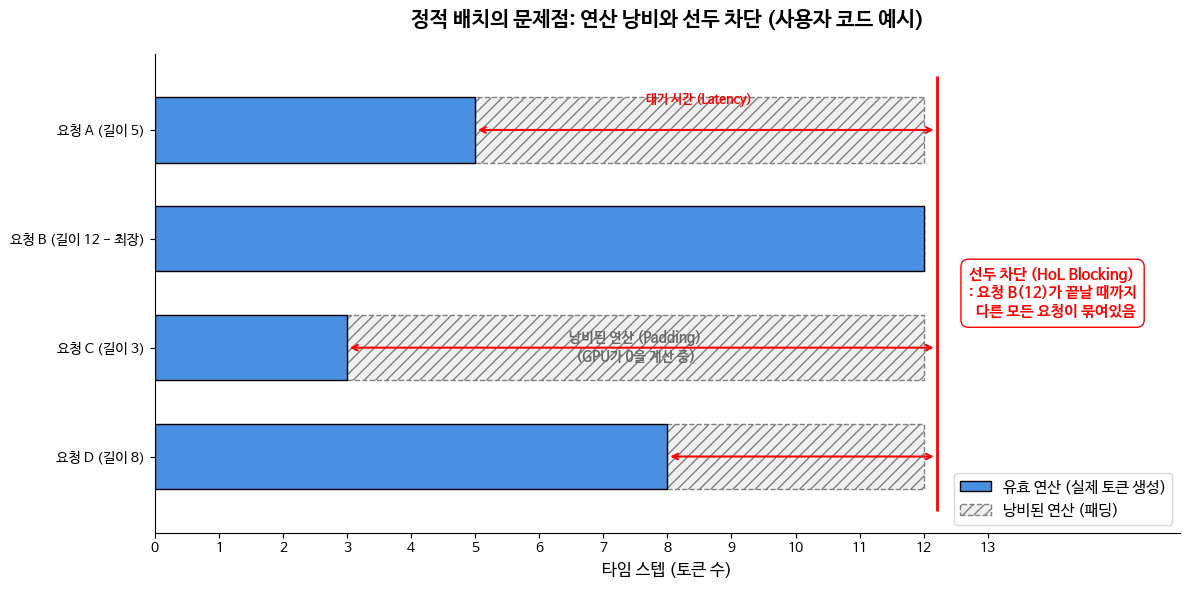

In [4]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np

# -----------------------------------------------------------
# [폰트 설정] Colab 환경용 (NanumBarunGothic)
# -----------------------------------------------------------
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# -----------------------------------------------------------
# [데이터 설정] 사용자 코드의 시나리오 반영
# -----------------------------------------------------------
# 요청 데이터: ID와 길이 (토큰 수)
requests = ['요청 A (길이 5)', '요청 B (길이 12 - 최장)', '요청 C (길이 3)', '요청 D (길이 8)']
lengths = [5, 12, 3, 8]

# 그래프는 아래에서 위로 그려지므로, 시각적으로 위에서 아래로(A->D) 보이기 위해 역순 정렬
requests_plot = requests[::-1]
valid_tokens = np.array(lengths[::-1])

# 패딩 계산 (가장 긴 요청 B의 길이에 맞춤)
max_len = 12
padding_tokens = max_len - valid_tokens

# -----------------------------------------------------------
# [그래프 그리기]
# -----------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))

# 1. 유효 연산 (파란색 막대) - 실제 의미 있는 토큰 생성 구간
ax.barh(requests_plot, valid_tokens, color='#4A90E2', label='유효 연산 (실제 토큰 생성)',
        edgecolor='black', height=0.6, zorder=3)

# 2. 낭비된 연산 (회색 빗금 막대) - 트랜스포머가 0을 계산하는 구간
bars_padding = ax.barh(requests_plot, padding_tokens, left=valid_tokens, color='#F0F0F0',
                       label='낭비된 연산 (패딩)', edgecolor='gray', linestyle='--', hatch='///', height=0.6, zorder=2)

# -----------------------------------------------------------
# [시각적 강조] GPU 낭비 및 선두 차단 표시
# -----------------------------------------------------------

# (1) 패딩 영역에 "낭비됨" 텍스트 추가 (가장 짧은 요청 C에 표시)
# 위치: 요청 C (위에서 3번째 -> 인덱스 1)의 패딩 중간 지점
padding_center_x = valid_tokens[1] + padding_tokens[1] / 2
ax.text(padding_center_x, 1, '낭비된 연산 (Padding)\n(GPU가 0을 계산 중)',
        fontsize=10, color='dimgray', ha='center', va='center', fontweight='bold')

# (2) 선두 차단 (Head-of-Line Blocking) 강조
# 가장 긴 요청 B(12토큰)가 끝나는 시점에 빨간 선 표시
line_x = 12.2
ax.vlines(x=line_x, ymin=-0.5, ymax=3.5, colors='red', linestyles='solid', linewidth=2, zorder=4)

# 대기 시간 화살표 그리기 (짧은 요청들이 긴 요청을 기다리는 시간)
for i, length in enumerate(valid_tokens):
    if length < max_len:
        # 끝난 지점부터 빨간 선까지 화살표
        ax.annotate('', xy=(line_x, i), xytext=(length, i),
                    arrowprops=dict(arrowstyle='<->', color='red', lw=1.5))

        # 맨 위 요청(A)에만 대표로 텍스트 표시
        if i == 3:
            ax.text((length + max_len)/2, i + 0.25, '대기 시간 (Latency)',
                    color='red', fontsize=9, ha='center', fontweight='bold')

# 선두 차단 설명 박스
ax.text(line_x + 0.5, 1.5, '선두 차단 (HoL Blocking)\n: 요청 B(12)가 끝날 때까지\n  다른 모든 요청이 묶여있음',
        color='red', va='center', fontweight='bold', fontsize=11,
        bbox=dict(facecolor='white', edgecolor='red', boxstyle='round,pad=0.5'))

# -----------------------------------------------------------
# [스타일링]
# -----------------------------------------------------------
ax.set_xlim(0, 16) # 오른쪽 설명 텍스트 공간 확보
ax.set_xticks(range(0, 14)) # x축 눈금 1단위로 설정
ax.set_xlabel('타임 스텝 (토큰 수)', fontsize=12)
ax.set_title(f'정적 배치의 문제점: 연산 낭비와 선두 차단 (사용자 코드 예시)', fontsize=15, fontweight='bold', pad=20)

# 불필요한 테두리 제거
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 범례 표시
ax.legend(loc='lower right', fontsize=11)

plt.tight_layout()
plt.show()